In [1]:
import os
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import sys

import glob
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys# less gpu heavy loss, SAM doesnt look good 
import glob

from torch.utils.data import Dataset
from typing import Optional, Callable, List, Dict, Tuple, Any
from tqdm import tqdm
import json
import wandb
from torchvision.utils import make_grid
from monai.losses.dice import DiceLoss
from monai.metrics.meandice import DiceMetric
from monai.metrics.cumulative_average import * 
from monai.metrics import *

torch.cuda.empty_cache()

In [2]:
! export CODE_PATH="/media/ana-caznok/SSD-08/recon-segment"
! export DATA_PATH="/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"

In [3]:
# Set visible CUDA devices
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/transforms")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/configs")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/plots")

In [6]:
from fixed_dataset import FixedDataset
from seg_recon_vit3d import SegRecon_ViT_3D
from transforms.factory import transform_factory
from utils.read_yaml import read_yaml
from utils.model_select import model_select
from loss import loss_select
from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore
from transforms import *
from transforms import FourierSpectralTransform
from transforms.ifft_transform import InverseFourierSpectralTransform
from transforms.inverse_factory import inverse_transform_factory

/home/ana-caznok/software/src/miniforge3/envs/agrvai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
config_path = "/media/ana-caznok/SSD-08/recon-segment/configs/"
config_name = 'restormer-seg_msi2mask.yaml'
config_file = config_name

In [8]:
config = read_yaml(config_path + config_name)

In [9]:
# --------------------- CONFIG ---------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = 1#config['train']['batch_size']
NUM_EPOCHS = 2#config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
TRANSFORM = config['train']['transform_index'].replace('gpu','cpu')
MODEL_NAME = config['model']
need_ifft = bool(config['ifft'])
transform2metrics = bool(config['transform2metrics']) if 'transform2metrics' in config else False
include_background = bool(config['include_background']) if 'include_background' in config else False

In [10]:
print(transform_factory(TRANSFORM))

None


## ------------------ DATASET + LOADER ------------------

In [11]:
# ------------------ DATASET + LOADER ------------------
train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
)

val_dataset = FixedDataset(
    mode="val",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),
    preprocessing=PREPROCESSING
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Number of face masks 234. initialized 234 images train DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None


## ------------------ TESTING TRANSFORM ------------------

In [ ]:
# ------------------ TESTING TRANSFORM ------------------
x, y, m = train_dataset[45]
print(x.shape)
print(y.shape)
x = x.cpu().numpy()
plt.imshow(x[2],cmap='gray')
plt.plot(128,100,'*')
plt.show()

## -------------- TESTING INVERSE TRANSFORM ----------------- 

In [ ]:
#-------------- TESTING INVERSE TRANSFORM ----------------- 

In [ ]:
original_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory('downsample_4'),  # You can define transforms here
    preprocessing=PREPROCESSING
)
x_oritinal, y_original, m_original = original_dataset[45]
y_original = y_original.cpu().numpy()
print(x_oritinal.shape)
print(y_original.shape)

In [ ]:
from ifft_transform import InverseFourierSpectralTransform
inverse_transform = InverseFourierSpectralTransform(
                        norm = 'minmax-byc',
                        channel_first = True, 
                        device = 'cpu', 
                        shift = False, 
                        stack_type = 'alternate')
inverse_transform_shift = InverseFourierSpectralTransform(
                        norm = 'minmax-byc',
                        channel_first = True, 
                        device = 'cpu', 
                        shift = True, 
                        stack_type = 'alternate')

In [ ]:
m['fft_xmax'].shape

In [ ]:
y.unsqueeze(0).shape

In [ ]:
y_ifft  = inverse_transform(y.unsqueeze(0),m).cpu().numpy()
y_ifft_shift = inverse_transform_shift(y.unsqueeze(0),m).cpu().numpy()

In [ ]:
y_ifft = y_ifft[0,:,:,:]
y_ifft_shift = y_ifft_shift[0,:,:,:]

In [ ]:
print(y_ifft.shape)

In [ ]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots with specified figure size
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot y_original[21, :, :] with grayscale colormap
axes[0, 0].imshow(y_original[21,:,:], cmap='gray')
imin, imax = y_original.min(), y_original.max()
axes[0, 0].set_title(f"y_original, minmax = [{imin:.2f}, {imax:.2f}]")
axes[0, 0].axis('off')  # Remove axis ticks

# Plot y[21, :, :]
axes[0, 1].imshow(y[21, :, :], cmap='gray')
imin, imax = y.min(), y.max()
axes[0, 1].set_title(f"fft shift, minmax = [{imin:.2f}, {imax:.2f}]")
axes[0, 1].axis('off')

# Plot y_transformed[21, :, :]
axes[1, 0].imshow(y_ifft[21, :, :], cmap='gray')
imin, imax = y_ifft.min(), y_ifft.max()
axes[1, 0].set_title(f"ifft, minmax = [{imin:.2f}, {imax:.2f}]")
axes[1, 0].axis('off')

# Plot y_transformed_shift[21, :, :]
axes[1, 1].imshow(y_ifft_shift[21, :, :], cmap='gray')
imin, imax = y_ifft_shift.min(), y_ifft_shift.max()
axes[1, 1].set_title(f"ifft + shift, minmax = [{imin:.2f}, {imax:.2f}]")
axes[1, 1].axis('off')

# Optimize spacing between plots
plt.tight_layout()

# Display all subplots in one figure
plt.show()


In [ ]:
np.arange(0,60, 10)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume y_original and y_ifft_shift are NumPy arrays of shape (C, H, W)
# Compute the difference
difference = y_original - y_ifft_shift

# Select the channels to visualize (e.g., every 10th from 0 to 50)
channels = np.arange(0, 60, 10)

# Compute global min and max for consistent color scale across subplots
vmin = np.min(difference[channels])
vmax = np.max(difference[channels])

# Create a subplot with one row and len(channels) columns
n_channels = len(channels)
fig, axes = plt.subplots(1, n_channels, figsize=(3 * n_channels, 3))

# Ensure axes is iterable
if n_channels == 1:
    axes = [axes]

# Plot each channel with the same vmin/vmax scale
for i, ch in enumerate(channels):
    ax = axes[i]
    im = ax.imshow(difference[ch], cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'Channel {ch}')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Adjust layout
plt.savefig('/media/ana-caznok/SSD-08/recon-segment/plots/iFFT_difference.png')
plt.tight_layout()
plt.show()

plt.plot(y_original[:,128,128],'orange',label = 'Original HSI')
plt.plot(y_ifft_shift[:,128,128],'-.m', label = 'FFT and iFFT HSI')
plt.legend()
plt.title('Spectral Difference')
plt.savefig('/media/ana-caznok/SSD-08/recon-segment/plots/iFFT_spectral_difference_byc.png')

In [ ]:
#O PROBLEMA EH A NORMALIZACAO DA IMAGEM, se nao fizermos normalizacao, a inversa sai igualzinha a original 
# o unico jeito seria fazer com que a rede ou aprenda entre -inf e + inf 

## ------------------ TESTING MULTIPLE TRANSFORMS ------------------

In [ ]:
# ------------------ TESTING MULTIPLE TRANSFORMS ------------------

BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = config['train']['batch_size']
NUM_EPOCHS = config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
MODEL_NAME = config['model']

testing_transforms = [
    'downs4_fft_D40_cube_minmax_gpu_shift',                      # D40 reflectance, shifted FFT, minmax
    'downs4_fft_D40_cube_minmax_gpu',                            # D40 reflectance, non-shifted FFT, minmax
    'downs4_fft_normal_cube_minmax_gpu_shift',                  # Normal reflectance, shifted FFT, minmax
    'downs4_fft_normal_cube_minmax_gpu',                        # Normal reflectance, non-shifted FFT, minmax
    'downs4_fft_double_D40_cube_minmax_gpu',                    # D40 reflectance, non-shifted FFT, real+imag
    'downs4_fft_double_D40_cube_gpu_minmax_shift',              # D40 reflectance, shifted FFT, real+imag
    'downs4_fft_double_normal_cube_minmax_gpu',                 # Normal reflectance, non-shifted FFT, real+imag
    'downs4_fft_double_normal_cube_gpu_minmax_shift',           # Normal reflectance, shifted FFT, real+imag
    'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous',# Normal reflectance, shifted FFT, real+imag, continuous stacking
    'downs4_fft_double-softmax_normal_cube_gpu_shift',          # Normal reflectance, shifted FFT, real+imag, softmax normalization
    'downs4_fft_double-none_normal_cube_gpu_shift'    # Normal reflectance, shifted FFT, real+imag, softmax normalization
]
x_transf_dict = {'full_img': {}, 
                 'spectre': {}}
y_transf_dict = {'full_img': {}, 
                 'spectre': {}}

for t in testing_transforms: 
    TRANSFORM = t

    train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
    )
    
    x, y, m = train_dataset[45]
    x = x.cpu().numpy()
    y = y.cpu().numpy()

    x_transf_dict['full_img'][t] = x
    y_transf_dict['full_img'][t] = y

    x_transf_dict['spectre'][t] = x[:,128,128]
    y_transf_dict['spectre'][t] = y[:,128,128]


    torch.cuda.empty_cache()

In [ ]:

def plot_transform_comparisons(x_transf_dict):
    """
    Plots comparisons of different spectral transforms using the 'spectre' data
    from x_transf_dict based on the new 'testing_transforms' 
    Comparisons include:
    - D40 vs Normal reflectance
    - Shifted vs Non-shifted FFT
    - Real+Imag vs Magnitude
    - Stacking methods (alternate vs continuous)
    - Normalization methods (minmax vs softmax)
    """
    plot_path = '/media/ana-caznok/SSD-08/recon-segment/plots/'
    # Extract the spectral data
    spectre_data = x_transf_dict['spectre']
    
    # Title mapping based on updated keys
    titles = {
        'downs4_fft_D40_cube_minmax_gpu_shift': 'D40, Shifted FFT, Magnitude',
        'downs4_fft_D40_cube_minmax_gpu': 'D40, Non-shifted FFT, Magnitude',
        'downs4_fft_normal_cube_minmax_gpu_shift': 'Normal, Shifted FFT, Magnitude',
        'downs4_fft_normal_cube_minmax_gpu': 'Normal, Non-shifted FFT, Magnitude',
        'downs4_fft_double_D40_cube_minmax_gpu': 'D40, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_D40_cube_gpu_minmax_shift': 'D40, Shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_minmax_gpu': 'Normal, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu_minmax_shift': 'Normal, Shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous': 'Normal, Shifted FFT, Real+Imag, Continuous',
        'downs4_fft_double-softmax_normal_cube_gpu_shift': 'Normal, Shifted FFT, Real+Imag, Softmax',
        'downs4_fft_double-none_normal_cube_gpu_shift': 'Normal, Shifted FFT, Real+Imag, NoNorm',
    }

    # === 1. D40 vs Normal (same FFT and representation) ===
    d40_vs_normal_pairs = [
        ('downs4_fft_D40_cube_minmax_gpu_shift', 'downs4_fft_normal_cube_minmax_gpu_shift'),
        ('downs4_fft_D40_cube_minmax_gpu', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_minmax_gpu', 'downs4_fft_double_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_sh.replace('gpu','cpu')ift', 'downs4_fft_double_normal_cube_gpu_minmax_shift'),
    ]
    
    plt.figure(figsize=(14, 10))
    for i, (d40, normal) in enumerate(d40_vs_normal_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[d40], label='D40')
        plt.plot(spectre_data[normal], label='Normal')
        plt.title(f"Reflectance Comparison\n({titles[d40].split(',')[1].strip()}, {titles[d40].split(',')[2].strip()})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "D40 vs Normal Reflectance"
    savetitle = suptitle.replace(' ', '_')
    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path +savetitle + '.png')
    plt.show()

    # === 2. Shifted vs Non-Shifted (same reflectance and representation) ===
    shift_vs_noshift_pairs = [
        ('downs4_fft_D40_cube_minmax_gpu_shift', 'downs4_fft_D40_cube_minmax_gpu'),
        ('downs4_fft_normal_cube_minmax_gpu_shift', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_shift', 'downs4_fft_double_D40_cube_minmax_gpu'),
        ('downs4_fft_double_normal_cube_gpu_minmax_shift', 'downs4_fft_double_normal_cube_minmax_gpu'),
    ]
    
    plt.figure(figsize=(14, 10))
    for i, (shifted, noshifted) in enumerate(shift_vs_noshift_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[shifted], label='Shifted FFT')
        plt.plot(spectre_data[noshifted], label='Non-Shifted FFT')
        reflectance = titles[shifted].split(',')[0]
        rep = titles[shifted].split(',')[2].strip()
        plt.title(f"FFT Shift Comparison\n({reflectance}, {rep})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "Shifted vs Non-Shifted FFT"
    savetitle = suptitle.replace(' ', '_')
    plt.suptitle("Shifted vs Non-Shifted FFT", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path + savetitle + '.png')
    plt.show()
    
    # === 3. Real+Imag vs Magnitude (same reflectance and shift) ===
    double_vs_single_pairs = [
        ('downs4_fft_double_D40_cube_minmax_gpu', 'downs4_fft_D40_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_shift', 'downs4_fft_D40_cube_minmax_gpu_shift'),
        ('downs4_fft_double_normal_cube_minmax_gpu', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_normal_cube_gpu_minmax_shift', 'downs4_fft_normal_cube_minmax_gpu_shift'),
    ]

    plt.figure(figsize=(14, 10))
    for i, (double, single) in enumerate(double_vs_single_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[double], label='Real+Imag (Double)')
        plt.plot(spectre_data[single], label='Magnitude (Single)')
        reflectance = titles[double].split(',')[0]
        shift = titles[double].split(',')[1].strip()
        plt.title(f"Spectral Representation\n({reflectance}, {shift})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "Real+Imag vs Minmax"
    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path + suptitle.replace(' ', '_') + '.png')
    plt.show()

    # === 4. Alternate vs Continuous stacking ===
    stacking_pair = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous'
    )
    plt.plot(spectre_data[stacking_pair[0]], label='Alternate')
    plt.plot(spectre_data[stacking_pair[1]], label='Continuous')
    title = "Alternate vs Continuous Stacking"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    savetitle = title.replace(' ', '_')
    plt.savefig(plot_path + savetitle + '.png')
    plt.show()

    # === 5. MinMax vs Softmax normalization ===
    norm_pair = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double-softmax_normal_cube_gpu_shift'
    )
    plt.plot(spectre_data[norm_pair[0]], label='MinMax')
    plt.plot(spectre_data[norm_pair[1]], label='Softmax')
    title = "MinMax vs Softmax Normalization"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.savefig(plot_path + title.replace(' ', '_') + '.png')
    plt.show()

    # === 6. Softmax vs NoNorm normalization ===
    norm_pair_2 = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double-none_normal_cube_gpu_shift'
    )
    plt.plot(spectre_data[norm_pair_2[0]], label='MinMax')
    plt.plot(spectre_data[norm_pair_2[1]], label='NoNorm')
    title = "MinMax vs NoNorm Normalization"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.savefig(plot_path + title.replace(' ', '_') + '.png')
    plt.show()


In [ ]:
x_transf_dict['spectre'].keys()

In [ ]:
plot_transform_comparisons(x_transf_dict)

In [ ]:
plot_transform_comparisons(y_transf_dict)

In [ ]:
y = y.cpu().numpy()
signal = y[:,30,300]
plt.plot(signal)
plt.show()
transf_signal = fft(signal)
shift = fftshift(transf_signal)

In [ ]:
shift.imag

In [ ]:
plt.plot(transf_signal.real)
plt.show()

plt.plot(shift.real)
plt.show()

## ------------------ DEBUGGING ALL FILES ------------------

In [ ]:
dataloader_debug = iter(train_loader)
x, y, m = next(dataloader_debug)

plt.imshow(make_grid(x[:, :3]).permute(1, 2, 0),cmap='gray')
plt.show()

for batch in tqdm(train_loader):
    pass

## ------------------MODEL DEFINING AND TRAINING ------------------

In [12]:
# ------------------ MODEL ------------------
model, resume_file = model_select(config)
model = model.to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

start_epoch=0
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

if need_ifft: 
    ifft_output_function = inverse_transform_factory(TRANSFORM,output=True)

Looking for checkpoint in models/restormer-seg_msi2mask.pth. Exact path only: True.
No checkpoint found or error loading — starting from scratch.
Could't find checkpoint models/restormer-seg_msi2mask.pth! :(
Selected model restormer-seg_4to61: Restormer_Seg


In [13]:
# LOSS
config['loss'] = 'L1Loss'
criterion = loss_select(config).to(DEVICE) #new
criterion_seg = DiceLoss(include_background=include_background,to_onehot_y=False)

Selecting loss: L1Loss


In [ ]:
x, y, m = train_dataset[45]
x2, y2, m2 = train_dataset[46]

x = torch.stack([x, x2], dim=0)
y = torch.stack([y, y2], dim=0)
m['mask'] = torch.stack([m['mask'], m2['mask']], dim=0)

In [ ]:
m['mask'].shape

In [ ]:
random_mask = torch.randint(low=0, high=2, size=m['mask'].shape, dtype=torch.float32)

In [ ]:
m['mask'].shape

In [ ]:
criterion_seg(m['mask'],m['mask']) #a mascara com ela mesma da 0 

In [ ]:
criterion_seg(m['mask'],random_mask) # com numeros aleatorios da um numero maior 

In [29]:
dice_metric = GeneralizedDiceScore(include_background=True, weight_type='square')

In [ ]:
len(val_dataset)

In [ ]:
dice_metric(m['mask'],m['mask']).mean()

In [ ]:
criterion(y.unsqueeze(0), y.unsqueeze(0))

In [ ]:
criterion(y.unsqueeze(0),- y.unsqueeze(0))

In [ ]:
def config2wandb(config):
    config_wandb = {} 
    for k in config: 
        if (k == 'train') or (k=='valid'): 
            for l in config[k]:
                config_wandb[k+'_'+l] = config[k][l]
        else: 
            config_wandb[k] = config[k]
    string_config = transform_factory(config['train']['transform_index']).__str__().replace('\n',' ')
    config_wandb['transform_steps'] = string_config
    return config_wandb

In [ ]:
import torch.nn.functional as F

In [ ]:
model

In [ ]:
x, y, m = train_dataset[45]
output, out_prob = model(x.unsqueeze(0))

In [ ]:
out_prob = torch.sigmoid(out_prob) 
mask = (out_prob > 0.5).float()


In [ ]:
out_prob = F.softmax(out_prob, dim=1)
print(out_prob.shape)
# The result is [batch_size, H, W] of ints (0 or 1)

mask = torch.argmax(out_prob, dim=1)
print(out_prob.shape)
mask = mask.float()

In [ ]:
mask.unique()

In [ ]:
out_prob = torch.sigmoid(mask) 

In [ ]:
trn_history = []
val_history = []

for epoch in range(start_epoch,2):
    model.train()
    train_loss = 0.0
    for x, y, meta in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad()

        output, out_prob1 = model(x)
        
        out_prob = torch.sigmoid(out_prob1) #turning probabilities into binary mask 
        mask = (out_prob <= 0.5).float()

        if need_ifft:
            output = ifft_output_function(output, meta)

        loss_rec = criterion(output, y)
        loss_seg = criterion_seg(mask, meta['mask'].to(DEVICE))
        loss = loss_rec + loss_seg
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    avg_train_loss = train_loss / len(train_loader)
    trn_history.append(avg_train_loss)

    if config['wandb']:
        wandb.log({f"Train Avg Loss {config['loss']}": avg_train_loss})
        wandb.log({"epoch": epoch})
        

    # ---------------------------------------------- EVAL LOOP --------------------------------------------------------
    model.eval()
    val_loss = 0.0
    i = 0
    ssim_function = StructuralSimilarityIndexMeasure().to('cpu')
    sam_function = SAMScore().to('cpu')
    dice_metric = GeneralizedDiceScore(include_background=True, weight_type='square') #1 when good, 0 when bad
    ssim = 0
    sam = 0
    dice =0

    with torch.no_grad():
        for x, y, meta in tqdm(val_loader, desc="Validation"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            output,out_prob = model(x)

            out_prob = torch.sigmoid(out_prob) #will need to change if more then one class
            mask = (out_prob <= 0.5).float()
            print('passei aqui')
            
            if need_ifft: 
                output = ifft_output_function(output,meta)
                
            loss_rec = criterion(output, y)
            loss_seg = criterion_seg(mask, meta['mask'].to(DEVICE))
            loss = loss_rec + loss_seg
            val_loss += loss.item()
            i += 1
            if transform2metrics: 
                print(f"meta shape {meta['fft_ymin'].shape}")
                print(f'y shape {y.shape}')
                y = ifft_y_function(y,meta)
                output = ifft_y_function(output,meta)

            ssim += ssim_function(output.cpu(),y.cpu())
            sam += sam_function(output.cpu(),y.cpu())


            # Accumulate dice metric inputs
            dice_metric(mask, meta['mask'].to(DEVICE))

    avg_val_loss = val_loss / len(val_loader)
    val_history.append(avg_val_loss)
    
    avg_ssim = ssim/len(val_loader)
    avg_sam = sam/len(val_loader)
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    #print(avg_sam)
    #print(avg_dice)square

    if config['wandb']:
        wandb.log({f"Validation Avg Loss {config['loss']}": avg_val_loss})
        wandb.log({"val_epoch": epoch})
        wandb.log({"SSIM": avg_ssim})
        wandb.log({"SAM": avg_sam})
        wandb.log({"DICE": avg_dice})

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

Epoch 1/2 - Training:   2%|▏         | 4/234 [00:17<16:44,  4.37s/it]


KeyboardInterrupt: 

In [22]:
mask.shape

torch.Size([1, 1, 256, 256])

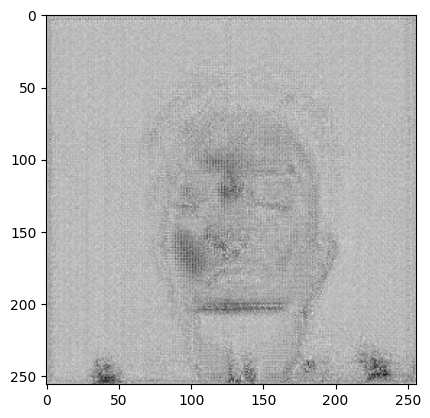

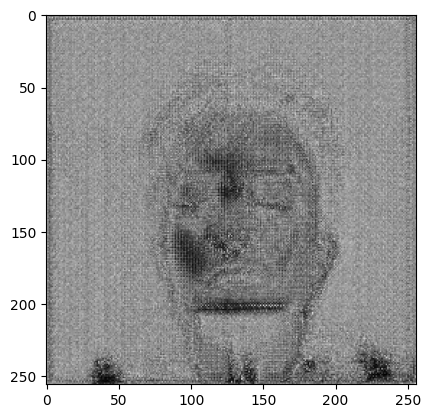

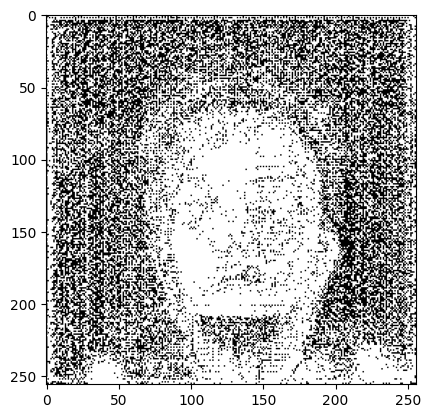

In [26]:
prob_show1 = out_prob1.detach().cpu().numpy()[0,0,:,:]
plt.imshow(prob_show1,cmap='gray')
plt.show()

prob_show = out_prob.detach().cpu().numpy()[0,0,:,:]
plt.imshow(prob_show,cmap='gray')
plt.show()

mask_show = mask.detach().cpu().numpy()[0,0,:,:]
plt.imshow(mask_show,cmap='gray')
plt.show()

In [ ]:
x.

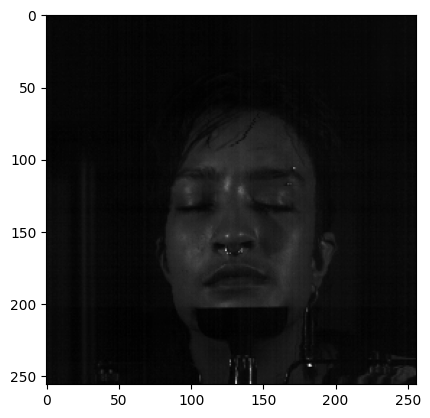

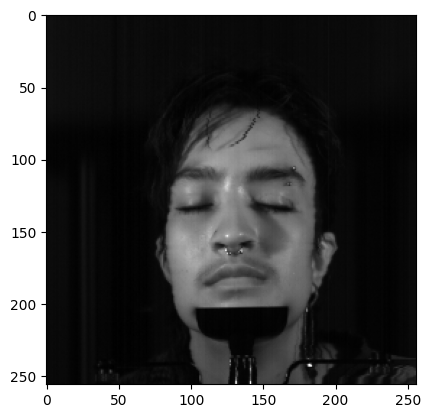

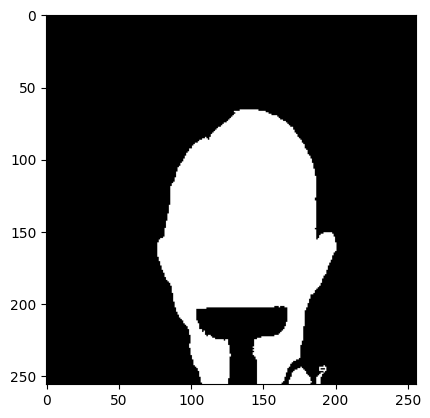

In [27]:
plt.imshow(x.detach().cpu().numpy()[0,2,:,:],cmap='gray')
plt.show()

plt.imshow(y.detach().cpu().numpy()[0,30,:,:],cmap='gray')
plt.show()

plt.imshow(meta['mask'][0,0,:,:],cmap='gray')
plt.show()

In [33]:
dice_metric = GeneralizedDiceScore(include_background=False, weight_type='simple')

In [34]:
dice_metric(mask, meta['mask'].to(DEVICE))

tensor([0.4821])

In [ ]:
output.size()

# cemiterio

In [ ]:
testing_transforms = ['donws4_fft_D40_cube_gpu_shift', 'downs4_fft_D40_cube_gpu', 
                      'donws4_fft_normal_cube_gpu_shift', 'downs4_fft_normal_cube_gpu',
                      'downs4_fft_double_D40_cube_gpu', 'downs4_fft_double_D40_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu', 'downs4_fft_double_normal_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu_shift_continuous', 
                      'downs4_fft_double-softmax_normal_cube_gpu_shift']

In [ ]:

    elif index =='fft_D40_x_gpu':
        
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',False, True , 'cuda')])
    elif index =='fft_D40_x_cpu':
        
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',False, True, 'cpu')])
    
    elif index =='fft_D40_cube_gpu':
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',True, True, 'cuda')])
    
    elif index =='downs4_fft_D40_cube_gpu_shift':    
        return Compose([Downsample(factor=4),RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',True, True, 'cuda', shift=True)])
    elif index =='downs4_fft_D40_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('minmax',True, True , 'cuda', shift=False)])
    
    elif index =='donws4_fft_normal_cube_gpu_shift':    
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'),FourierSpectralTransform('minmax',True, True, 'cuda', shift=True)])
    elif index =='downs4_fft_normal_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('minmax',True, True , 'cuda', shift=False)])
    
    elif index =='downs4_fft_double_D40_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=False)])
    elif index =='downs4_fft_double_D40_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double_normal_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=False)])
    elif index =='downs4_fft_double_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double-softmax_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('softmax',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double-none_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm', True), FourierSpectralTransform('None',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double_normal_cube_gpu_shift_invert':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True, invert=True)])
    

    elif index =='downs4_fft_double_normal_cube_gpu_shift_continuous':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True, stack_type='continuous')])
    
    elif index =='downs2_fft_D40_x_gpu':
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'), Downsample(factor=2), FourierSpectralTransform('minmax',False, True , 'cuda')])
    
    elif index=='stft_D40_x_gpu': 
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'),Spectrogram4D(2, 5,32,'abs',device='cuda')])
    elif index=='stft_D40_x_cpu': 
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'),Spectrogram4D(2, 5,32,'abs',device='cpu')])

In [ ]:
def preprocess_for_unit_fft_torch(image):
    """
    Normalize a [C, H, W] image tensor so its FFT along channel axis has real and imaginary parts in [0, 1].

    Args:
        image (torch.Tensor): Input tensor [C, H, W] on GPU, values in [0, 1].

    Returns:
        fft_real (torch.Tensor): Real part of FFT, in [0, 1]
        fft_imag (torch.Tensor): Imag part of FFT, in [0, 1]
    """
    # L1 norm per pixel across spectral channels
    l1_norm = image.abs().sum(dim=0, keepdim=True)  # [1, H, W]
    l1_norm = torch.clamp(l1_norm, min=1e-8)         # prevent div by zero

    # Scale so L1 norm <= 0.5
    image_scaled = 0.5 * image / l1_norm             # [C, H, W]

    # FFT along spectral axis (dim=0)
    fft_result = torch.fft.fft(image_scaled, dim=0)

    # Shift real and imag parts to [0, 1]
    fft_real = fft_result.real + 0.5
    fft_imag = fft_result.imag + 0.5

    return fft_real, fft_imag

# Example usage:
image = torch.rand((31, 64, 64), device='cpu')  # random input
fft_real, fft_imag = preprocess_for_unit_fft_torch(x)

# Check ranges
print("Real part range:", fft_real.min().item(), fft_real.max().item())
print("Imag part range:", fft_imag.min().item(), fft_imag.max().item())